# Telco Customer Churn EDA

This notebook explores the Telco Customer Churn dataset to understand customer churn patterns. The analysis focuses on identifying business signals that can support churn modeling and retention recommendations.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

We start by preparing the analysis toolkit. In this churn story, these libraries help answer three core questions: who churns, what patterns separate churned customers from retained customers, and what business actions can reduce churn risk.

In [2]:
current_dir = Path.cwd().resolve()

if current_dir.name == "churn_prediction":
    PROJECT_DIR = current_dir
elif "churn_prediction" in current_dir.parts:
    PROJECT_DIR = current_dir
    while PROJECT_DIR.name != "churn_prediction":
        PROJECT_DIR = PROJECT_DIR.parent
elif (current_dir / "projects" / "churn_prediction").exists():
    PROJECT_DIR = current_dir / "projects" / "churn_prediction"
else:
    raise FileNotFoundError("Could not locate the churn_prediction project folder.")

RAW_DATA_PATH = PROJECT_DIR / "data" / "raw" / "telco_customer_churn.csv"
PROCESSED_DATA_PATH = PROJECT_DIR / "data" / "processed" / "churn_clean.csv"

RAW_DATA_PATH, PROCESSED_DATA_PATH

(WindowsPath('D:/Self Project/SumoPod API/Profile/projects/churn_prediction/data/raw/telco_customer_churn.csv'),
 WindowsPath('D:/Self Project/SumoPod API/Profile/projects/churn_prediction/data/processed/churn_clean.csv'))

This cell ensures the notebook can locate the correct project folder. A strong analysis should be reproducible, not dependent on a single local working directory.

In [3]:
raw_df = pd.read_csv(RAW_DATA_PATH)
df = pd.read_csv(PROCESSED_DATA_PATH)

df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,monthly_charges,total_charges,churn,is_churned,has_internet_service,has_month_to_month_contract,has_automatic_payment,avg_monthly_total_ratio,tenure_group,monthly_charge_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,29.85,No,0,1,1,0,29.850000,0-12 months,low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,56.95,1889.50,No,0,1,0,0,55.573529,25-48 months,medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,53.85,108.15,Yes,1,1,1,0,54.075000,0-12 months,medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,42.30,1840.75,No,0,1,0,1,40.905556,25-48 months,medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,70.70,151.65,Yes,1,1,1,0,75.825000,0-12 months,high


We load both the raw and processed datasets. The main analysis uses the processed data because the cleaning and feature engineering steps are already documented in `prepare_data.py`.

In [4]:
df.shape

(7043, 28)

Dataset size gives context for the analysis. With 7,043 customers, this dataset is large enough to reveal early churn patterns and support a reasonable baseline model.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  7043 non-null   str    
 1   gender                       7043 non-null   str    
 2   senior_citizen               7043 non-null   int64  
 3   partner                      7043 non-null   str    
 4   dependents                   7043 non-null   str    
 5   tenure                       7043 non-null   int64  
 6   phone_service                7043 non-null   str    
 7   multiple_lines               7043 non-null   str    
 8   internet_service             7043 non-null   str    
 9   online_security              7043 non-null   str    
 10  online_backup                7043 non-null   str    
 11  device_protection            7043 non-null   str    
 12  tech_support                 7043 non-null   str    
 13  streaming_tv                 

Before looking for insights, we inspect the data structure. Data types and non-null counts help confirm that key fields are ready for analysis and that no hidden quality issue weakens the conclusions.

In [6]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

Missing values are part of the data quality story. If many important values are missing, insights can become biased. In this processed dataset, important missing values have already been handled.

In [7]:
df.duplicated().sum()

np.int64(0)

Duplicate rows are checked to make sure no customer record is counted more than once. A reliable business story depends on treating each record consistently.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
senior_citizen,7043.0,0.162147,0.368612,0.00,0.000,0.00,0.000000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.00,55.000000,72.00
monthly_charges,7043.0,64.761692,30.090047,18.25,35.500,70.35,89.850000,118.75
total_charges,7043.0,2279.734304,2266.794470,0.00,398.550,1394.55,3786.600000,8684.80
is_churned,7043.0,0.265370,0.441561,0.00,0.000,0.00,1.000000,1.00
has_internet_service,7043.0,0.783331,0.412004,0.00,1.000,1.00,1.000000,1.00
has_month_to_month_contract,7043.0,0.550192,0.497510,0.00,0.000,1.00,1.000000,1.00
has_automatic_payment,7043.0,0.435326,0.495835,0.00,0.000,0.00,1.000000,1.00
avg_monthly_total_ratio,7043.0,64.698218,30.270670,0.00,35.649,70.30,90.174158,121.40


Numeric statistics provide the first view of customer scale: how long customers stay, how much they pay monthly, and how total charges are distributed. This sets the context before analyzing churn behavior.

In [9]:
df.describe(include="object").T

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31688\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
customer_id,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
partner,7043,2,No,3641
dependents,7043,2,No,4933
phone_service,7043,2,Yes,6361
multiple_lines,7043,3,No,3390
internet_service,7043,3,Fiber optic,3096
online_security,7043,3,No,3498
online_backup,7043,3,No,3088
device_protection,7043,3,No,3095


Categorical statistics show the customer mix across services, contracts, and payment methods. This helps identify which segments should be compared in the churn story.

In [10]:
churn_counts = df["churn"].value_counts()
churn_rate = df["is_churned"].mean()

churn_counts, churn_rate

(churn
 No     5174
 Yes    1869
 Name: count, dtype: int64,
 np.float64(0.2653698707936959))

Churn rate is the central tension in this analysis. Around one quarter of customers churn, which makes the issue large enough to matter while still creating class imbalance for modeling.

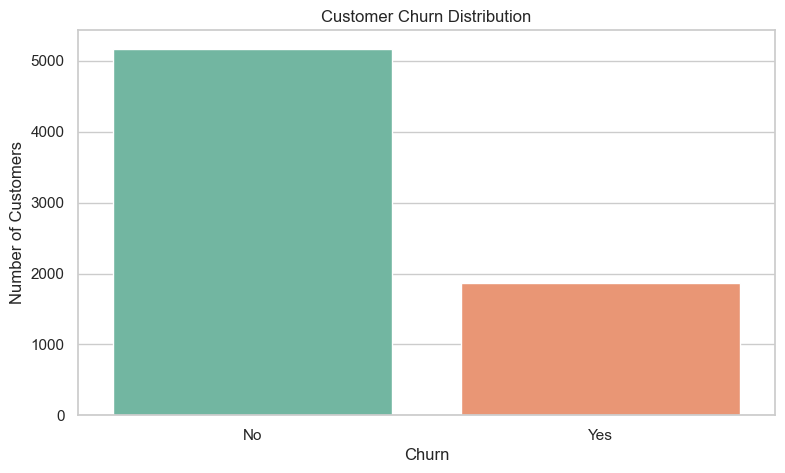

In [11]:
ax = sns.countplot(data=df, x="churn", hue="churn", palette="Set2", legend=False)
ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
plt.show()

**Business Insight:**

This chart shows the scale of churn. Most customers are retained, but the churned group is still large enough to affect revenue and should be a priority for retention campaigns.

In [12]:
contract_churn = (
    df.groupby("contract", as_index=False)
    .agg(customers=("customer_id", "count"), churn_rate=("is_churned", "mean"))
    .sort_values("churn_rate", ascending=False)
)
contract_churn

,contract,customers,churn_rate
0,Month-to-month,3875,0.427097
1,One year,1473,0.112695
2,Two year,1695,0.028319


Contract type is one of the strongest business signals. By comparing churn rates across contract types, we can see whether customer commitment level is related to retention.

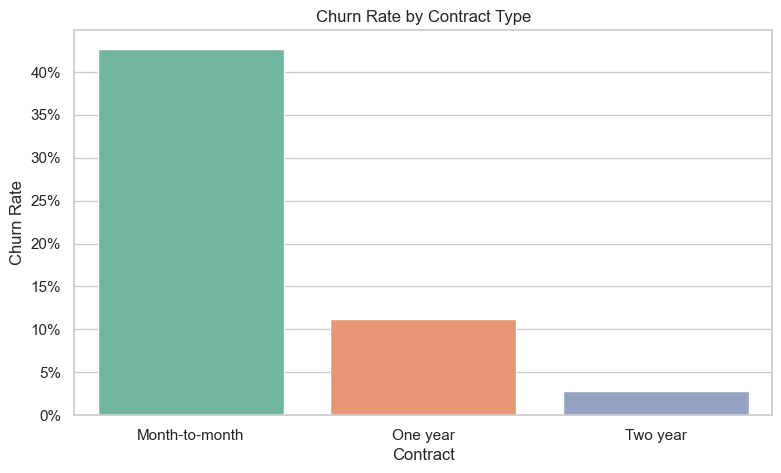

In [13]:
ax = sns.barplot(data=contract_churn, x="contract", y="churn_rate", hue="contract", palette="Set2", legend=False)
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()

**Business Insight:**

Month-to-month customers are much more likely to churn. The business implication is clear: lower contract commitment creates higher churn risk, so contract upgrade campaigns may help improve retention.

In [14]:
internet_churn = (
    df.groupby("internet_service", as_index=False)
    .agg(customers=("customer_id", "count"), churn_rate=("is_churned", "mean"))
    .sort_values("churn_rate", ascending=False)
)
internet_churn

,internet_service,customers,churn_rate
1,Fiber optic,3096,0.418928
0,DSL,2421,0.189591
2,No,1526,0.074050


Internet service type provides context about the product experience. If churn is concentrated in one service type, the root cause may involve price, service quality, expectations, or support.

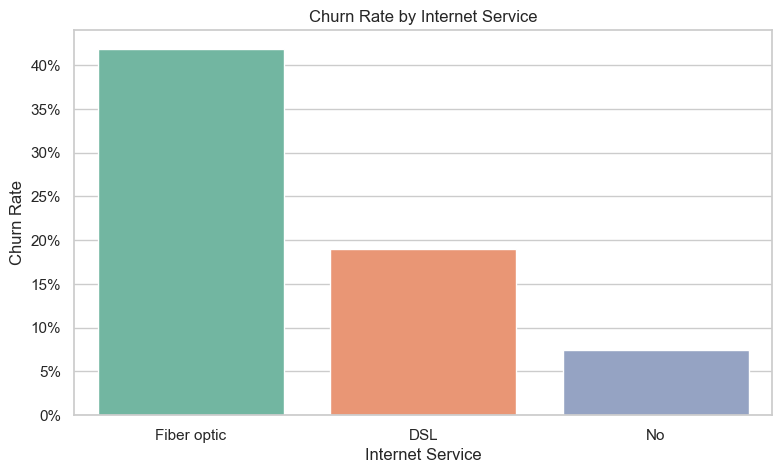

In [15]:
ax = sns.barplot(data=internet_churn, x="internet_service", y="churn_rate", hue="internet_service", palette="Set2", legend=False)
ax.set_title("Churn Rate by Internet Service")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()

**Business Insight:**

Fiber optic customers show a higher churn rate. This does not automatically mean the product is poor, but it does suggest that this segment should be reviewed alongside monthly charges and support usage.

In [16]:
payment_churn = (
    df.groupby("payment_method", as_index=False)
    .agg(customers=("customer_id", "count"), churn_rate=("is_churned", "mean"))
    .sort_values("churn_rate", ascending=False)
)
payment_churn

,payment_method,customers,churn_rate
2,Electronic check,2365,0.452854
3,Mailed check,1612,0.191067
0,Bank transfer (automatic),1544,0.167098
1,Credit card (automatic),1522,0.152431


Payment method can act as a proxy for payment friction and customer commitment. Automatic payments often indicate more stable customers, while manual payment methods can be linked with higher churn risk.

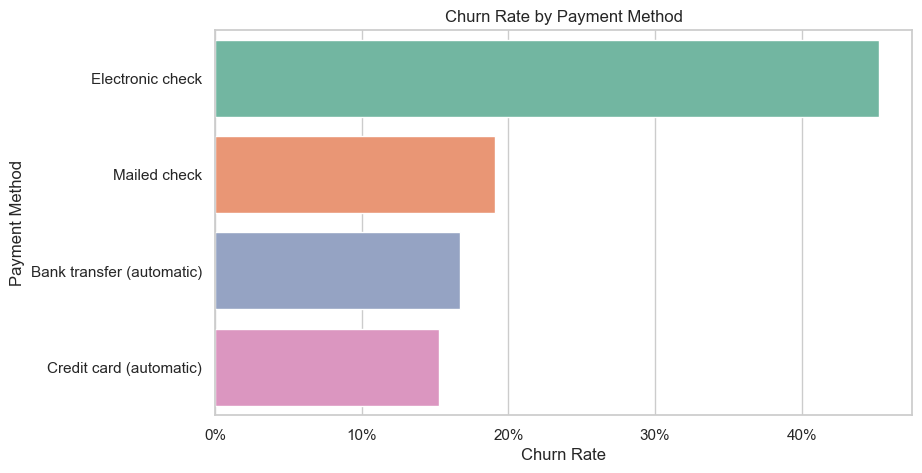

In [17]:
ax = sns.barplot(data=payment_churn, x="churn_rate", y="payment_method", hue="payment_method", palette="Set2", legend=False)
ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Churn Rate")
ax.set_ylabel("Payment Method")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()

**Business Insight:**

Electronic check customers have the highest churn rate. The business could test campaigns that encourage these customers to move toward automatic payment methods or receive better payment reminders.

In [18]:
tenure_churn = (
    df.groupby("tenure_group", as_index=False)
    .agg(customers=("customer_id", "count"), churn_rate=("is_churned", "mean"))
    .sort_values("tenure_group")
)
tenure_churn

,tenure_group,customers,churn_rate
0,0-12 months,2186,0.474382
1,13-24 months,1024,0.287109
2,25-48 months,1594,0.203890
3,49-72 months,2239,0.095132


Tenure answers a key question: when are customers most likely to leave? Segmenting tenure helps decide whether retention should focus on onboarding, early customer experience, or long-term loyalty.

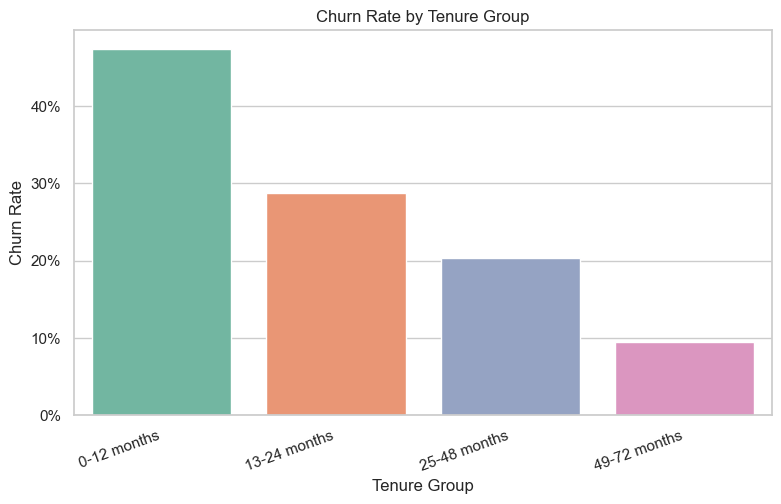

In [19]:
ax = sns.barplot(data=tenure_churn, x="tenure_group", y="churn_rate", hue="tenure_group", palette="Set2", legend=False)
ax.set_title("Churn Rate by Tenure Group")
ax.set_xlabel("Tenure Group")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.xticks(rotation=20, ha="right")
plt.show()

**Business Insight:**

Customers in the 0-12 month tenure group are the most vulnerable to churn. This supports an early-life retention strategy focused on onboarding, proactive follow-up, and quickly demonstrating product value.

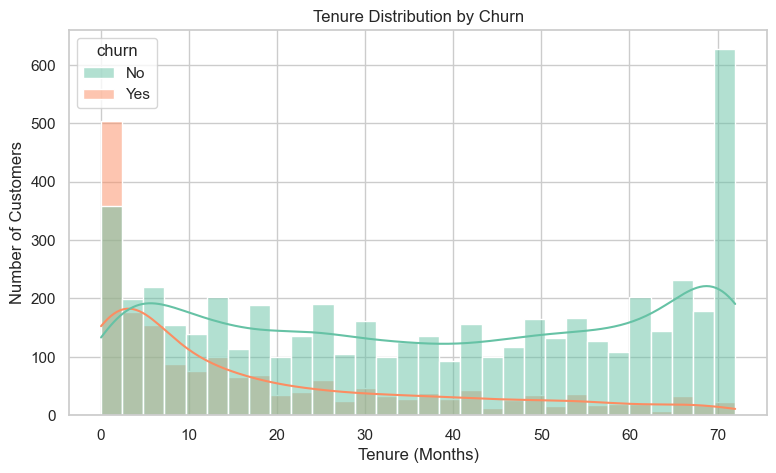

In [20]:
sns.histplot(data=df, x="tenure", hue="churn", bins=30, kde=True, palette="Set2")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

**Business Insight:**

The tenure distribution reinforces the same story: churn is concentrated among newer customers. As customers stay longer, churn risk generally declines.

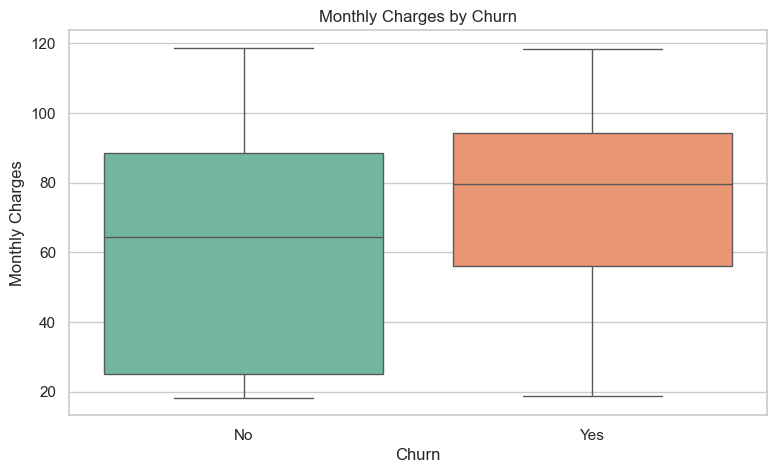

In [21]:
sns.boxplot(data=df, x="churn", y="monthly_charges", hue="churn", palette="Set2", legend=False)
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

**Business Insight:**

Churned customers tend to have higher monthly charges. This suggests that perceived value for money should be reviewed, especially for customers with high bills and flexible contracts.

In [22]:
service_cols = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
]

service_summary = []
for col in service_cols:
    temp = (
        df.groupby(col)["is_churned"]
        .mean()
        .reset_index()
        .assign(service=col)
        .rename(columns={col: "status", "is_churned": "churn_rate"})
    )
    service_summary.append(temp)

service_summary = pd.concat(service_summary, ignore_index=True)
service_summary.head(12)

,status,churn_rate,service
0,No,0.417667,online_security
1,No internet service,0.074050,online_security
2,Yes,0.146112,online_security
3,No,0.399288,online_backup
4,No internet service,0.074050,online_backup
5,Yes,0.215315,online_backup
6,No,0.391276,device_protection
7,No internet service,0.074050,device_protection
8,Yes,0.225021,device_protection
9,No,0.416355,tech_support


Add-on services such as online security and tech support can shape the customer experience. This analysis checks whether support and protection services are associated with stronger retention.

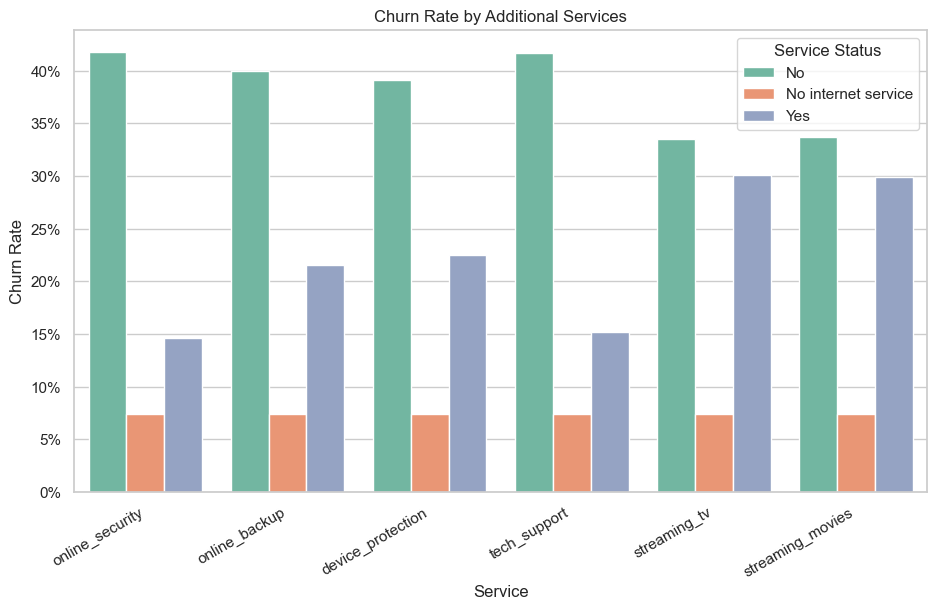

In [23]:
plt.figure(figsize=(11, 6))
sns.barplot(data=service_summary, x="service", y="churn_rate", hue="status", palette="Set2")
plt.title("Churn Rate by Additional Services")
plt.xlabel("Service")
plt.ylabel("Churn Rate")
plt.xticks(rotation=30, ha="right")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.legend(title="Service Status")
plt.show()

**Business Insight:**

Customers without certain support services are more likely to churn. A practical business recommendation is to offer support bundles or educate high-risk customers about the value of these services.

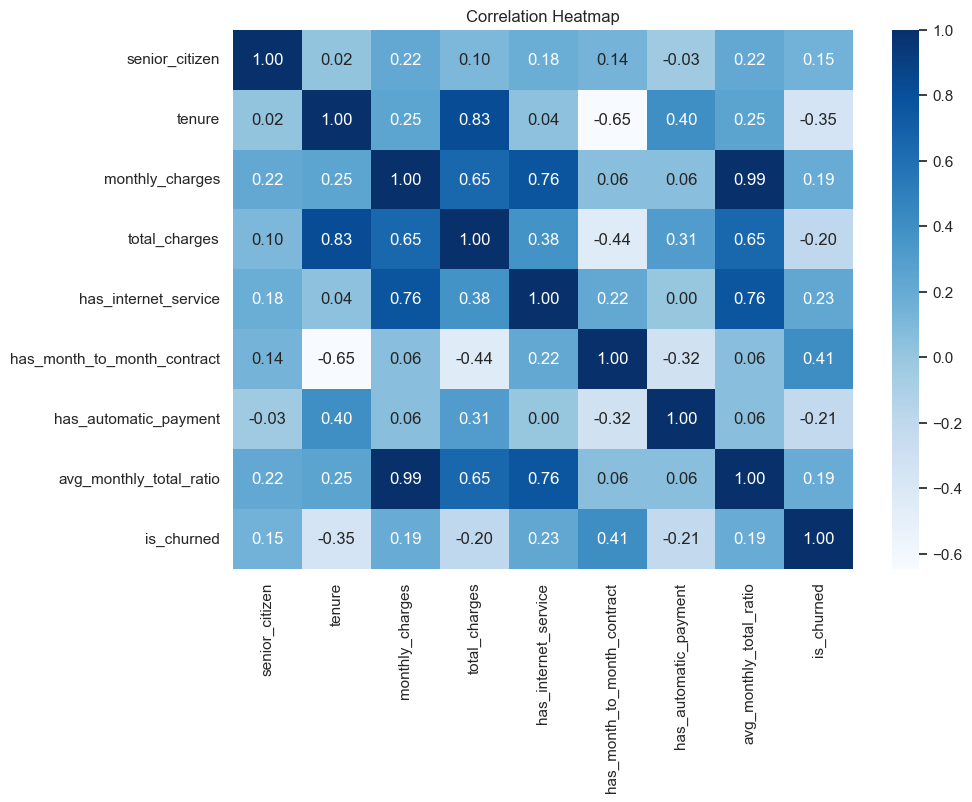

In [24]:
numeric_cols = [
    "senior_citizen",
    "tenure",
    "monthly_charges",
    "total_charges",
    "has_internet_service",
    "has_month_to_month_contract",
    "has_automatic_payment",
    "avg_monthly_total_ratio",
    "is_churned",
]

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The heatmap summarizes relationships between numeric features. It is not the final answer, but it helps identify which features may be useful for modeling and which relationships should be interpreted carefully.

In [25]:
risk_summary = pd.DataFrame({
    "business_factor": [
        "Month-to-month contract",
        "Fiber optic internet",
        "Electronic check payment",
        "Tenure 0-12 months",
        "High monthly charges",
    ],
    "churn_rate": [
        df.loc[df["contract"] == "Month-to-month", "is_churned"].mean(),
        df.loc[df["internet_service"] == "Fiber optic", "is_churned"].mean(),
        df.loc[df["payment_method"] == "Electronic check", "is_churned"].mean(),
        df.loc[df["tenure_group"] == "0-12 months", "is_churned"].mean(),
        df.loc[df["monthly_charge_group"] == "high", "is_churned"].mean(),
    ],
})

risk_summary.sort_values("churn_rate", ascending=False)

,business_factor,churn_rate
3,Tenure 0-12 months,0.474382
2,Electronic check payment,0.452854
0,Month-to-month contract,0.427097
1,Fiber optic internet,0.418928
4,High monthly charges,0.353614


**Business Insight:**

The risk summary turns the analysis into action priorities. Month-to-month contracts, short tenure, electronic check payments, and high monthly charges can be used to prioritize customers for retention campaigns.

## EDA Summary

The Telco dataset is more suitable for churn prediction than the previous e-commerce churn dataset because the target `Churn` is clear and the business features are relevant.

Key findings:

1. Overall churn rate is around 26.5%.
2. Month-to-month customers have much higher churn than one-year or two-year contract customers.
3. Customers with 0-12 months of tenure are the most vulnerable segment.
4. Fiber optic service and electronic check payment are associated with higher churn rates.
5. Churned customers tend to have higher monthly charges.
6. Support services such as online security and tech support are important retention signals.

Next step: use these insights to support a modeling notebook focused on Telco features and the `is_churned` target.